# Similarity-Pruned Dataset Workflow

Select one random anchor graph, compute vectorized embeddings for all graphs,
define a regression target as cosine similarity to that anchor,
remove the top-`k` most similar graphs, and continue with the pruned dataset.


In [1]:
%matplotlib inline
import math
import hashlib
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from NSPPK.nsppk import NSPPK

from coco_grape.visualizer.mol_display import draw_molecules

try:
    from notebooks.notebook_utils import (
        infer_display_mode,
        plot_networkx_graphs,
        plot_similarity_distribution_with_iqr,
    )
except ModuleNotFoundError:
    from notebook_utils import (
        infer_display_mode,
        plot_networkx_graphs,
        plot_similarity_distribution_with_iqr,
    )


# Auxiliary code

In [2]:
# Configuration moved below the experiment title.


In [3]:
# Dataset builder moved to notebooks/demo_pipeline_utils.py
try:
    from notebooks.demo_pipeline_utils import build_dataset
except ModuleNotFoundError:
    from demo_pipeline_utils import build_dataset


In [4]:
def compute_graph_embeddings(graphs, nbits=11):
    graph_vectorizer = NSPPK(
        radius=2,
        distance=4,
        connector=1,
        nbits=nbits,
        dense=True,
        parallel=True,
        use_edges_as_features=True,
    )
    embeddings = np.asarray(graph_vectorizer.fit_transform(graphs), dtype=np.float32)
    return graph_vectorizer, embeddings


def prune_by_anchor_similarity(graphs, targets, embeddings, k_remove=5, random_state=42, remove_anchor=False):
    if len(graphs) == 0:
        raise ValueError("Cannot prune an empty dataset.")
    if k_remove < 0:
        raise ValueError("k_remove must be >= 0.")
    if k_remove >= len(graphs):
        raise ValueError("k_remove must be smaller than the dataset size.")

    rng = np.random.default_rng(random_state)
    anchor_idx = int(rng.integers(low=0, high=len(graphs)))

    anchor_vec = embeddings[anchor_idx:anchor_idx + 1]
    similarity = cosine_similarity(embeddings, anchor_vec).ravel()

    ranking = np.argsort(-similarity)
    ordered = [idx for idx in ranking if (remove_anchor or idx != anchor_idx)]
    remove_indices = np.asarray(ordered[:k_remove], dtype=int)

    keep_mask = np.ones(len(graphs), dtype=bool)
    keep_mask[remove_indices] = False

    pruned_graphs = [g for g, keep in zip(graphs, keep_mask) if keep]
    pruned_targets = np.asarray([t for t, keep in zip(targets, keep_mask) if keep])
    pruned_similarity = similarity[keep_mask]

    removed_similarity = similarity[remove_indices]

    summary = pd.DataFrame({
        'graph_index': np.arange(len(graphs)),
        'target': targets,
        'cosine_to_anchor': similarity,
        'is_anchor': np.arange(len(graphs)) == anchor_idx,
        'removed': ~keep_mask,
    }).sort_values('cosine_to_anchor', ascending=False)

    return {
        'anchor_idx': anchor_idx,
        'anchor_graph': graphs[anchor_idx],
        'anchor_target': targets[anchor_idx],
        'similarity_target': similarity,
        'remove_indices': remove_indices,
        'removed_similarity': removed_similarity,
        'summary': summary,
        'pruned_graphs': pruned_graphs,
        'pruned_targets': pruned_targets,
        'pruned_similarity_target': pruned_similarity,
        'keep_mask': keep_mask,
    }


## Strict CFG Experiment: Similarity to Hidden Target Graph

Train `EquilibriumMatchingDecompositionalGraphGenerator` on the pruned dataset with the regression target
`working_similarity_target`, then generate with `desired_target=1.0` and `desired_target=0.7`
and compare average cosine similarity to the hidden anchor graph.


In [5]:
# Configuration
from pathlib import Path

REPO_ROOT = next(
    candidate.resolve()
    for candidate in [Path.cwd(), Path.cwd().parent]
    if (candidate / 'equilibrium_matching_decompositional_graph_generator').exists()
)
MODEL_PATH = REPO_ROOT / '.artifacts' / 'saved_models' / 'similarity_graph_generator.pkl'


In [6]:
import sys
from pathlib import Path

for _root in [Path.cwd(), *Path.cwd().parents[:2]]:
    if (_root / 'equilibrium_matching_decompositional_graph_generator').exists():
        _root_str = str(_root.resolve())
        if _root_str not in sys.path:
            sys.path.insert(0, _root_str)
        break
else:
    raise ModuleNotFoundError("Could not locate 'equilibrium_matching_decompositional_graph_generator' package from current working directory.")

del _root, _root_str

from NSPPK.nsppk import NSPPK, NodeNSPPK
from AbstractGraph.abstract_graph_operators import compose, cycle, neighborhood, unlabel
from AbstractGraph.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
    WithinRangeFeasibilityEstimatorFromNumericalFunction,
)
from equilibrium_matching_decompositional_graph_generator.node_engine import EquilibriumMatchingDecompositionalNodeGenerator
from equilibrium_matching_decompositional_graph_generator.graph_engine import (
    EquilibriumMatchingDecompositionalGraphDecoder,
    EquilibriumMatchingDecompositionalGraphGenerator,
)


In [7]:
import dill as pickle

try:
    from notebooks.demo_pipeline_utils import build_graph_generator
except ModuleNotFoundError:
    from demo_pipeline_utils import build_graph_generator


def save_graph_generator(graph_generator, model_path=MODEL_PATH):
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    with open(model_path, 'wb') as f:
        pickle.dump(graph_generator, f)
    print(f"Saved graph generator to {model_path}")
    return model_path


def load_graph_generator(model_path=MODEL_PATH):
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f"Saved generator model not found: {model_path}")
    with open(model_path, 'rb') as f:
        loaded_generator = pickle.load(f)
    print(f"Loaded graph generator from {model_path}")
    return loaded_generator


def build_similarity_optimization_dataset(
    dataset_type='MOLECULAR',
    dataset_size=2000,
    size=30,
    k_remove=5,
    assay_id='651610',
    embedding_nbits=11,
    random_state=42,
    remove_anchor=False,
):
    graphs, targets = build_dataset(
        dataset_type=dataset_type,
        dataset_size=dataset_size,
        size=size,
        assay_id=assay_id,
    )
    print(f"Loaded graphs: {len(graphs)}")
    if len(targets) > 0:
        target_array = np.asarray(targets)
        if np.issubdtype(target_array.dtype, np.integer):
            print(f"Class split: {np.bincount(target_array.astype(int))}")
    else:
        target_array = np.asarray(targets)

    graph_vectorizer, embeddings = compute_graph_embeddings(graphs, nbits=embedding_nbits)
    print(f"Embeddings shape: {embeddings.shape}")

    result = prune_by_anchor_similarity(
        graphs=graphs,
        targets=target_array,
        embeddings=embeddings,
        k_remove=k_remove,
        random_state=random_state,
        remove_anchor=remove_anchor,
    )

    display(result['summary'].head(12))
    display_mode = infer_display_mode(graphs)
    print("Anchor graph:")
    plot_networkx_graphs([result['anchor_graph']], n_cols=1, mode=display_mode)

    removed_graphs = [graphs[i] for i in result['remove_indices']]
    print(f"Removed top-{len(removed_graphs)} most similar graphs:")
    plot_networkx_graphs(removed_graphs, n_cols=max(1, len(removed_graphs)), mode=display_mode)

    working_graphs = result['pruned_graphs']
    working_targets = result['pruned_targets']
    working_similarity_target = result['pruned_similarity_target']
    print(f"working_graphs: {len(working_graphs)}")
    print(f"working_targets: {len(working_targets)}")
    print(f"working_similarity_target shape: {working_similarity_target.shape}")
    print(f"cosine target range: [{working_similarity_target.min():.4f}, {working_similarity_target.max():.4f}]")

    return working_graphs, working_similarity_target, result['anchor_graph'], graph_vectorizer


def cosine_to_hidden_target(graphs_to_compare, hidden_graph, fitted_graph_vectorizer):
    if len(graphs_to_compare) == 0:
        return np.array([], dtype=float)
    hidden_embedding = np.asarray(fitted_graph_vectorizer.transform([hidden_graph]), dtype=np.float32)
    generated_embeddings = np.asarray(fitted_graph_vectorizer.transform(graphs_to_compare), dtype=np.float32)
    return cosine_similarity(generated_embeddings, hidden_embedding).ravel()


---

# Experiment

[21:47:39] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 6 ignored
[21:47:40] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[21:47:40] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[21:47:40] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[21:47:40] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[21:47:40] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[21:47:40] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[21:47:40] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[21:47:42] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[21:47:45] WARNING: not removing hydrogen atom without neighbors


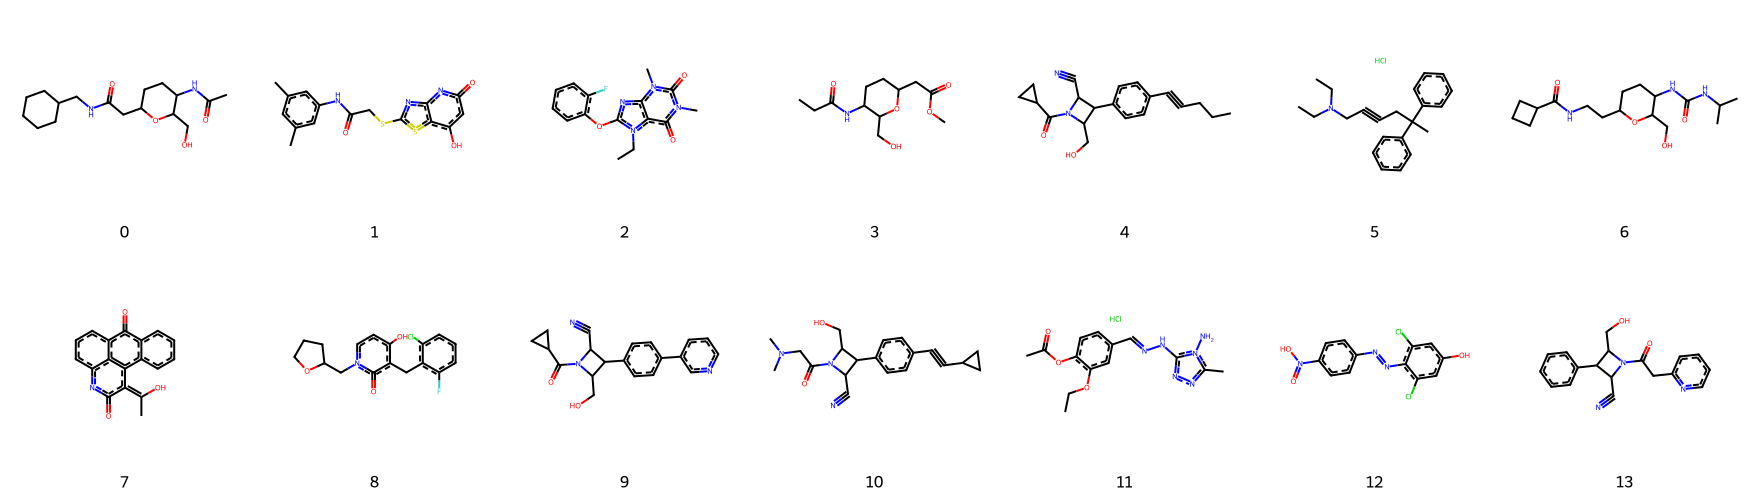

Loaded graphs: 722
Class split: [488 234]
Embeddings shape: (722, 2048)


,graph_index,target,cosine_to_anchor,is_anchor,removed
64,64,0,1.000000,True,False
85,85,0,1.000000,False,True
546,546,0,0.989581,False,True
664,664,0,0.985182,False,True
372,372,0,0.977209,False,True
275,275,0,0.968732,False,True
646,646,0,0.967989,False,False
276,276,0,0.967989,False,False
418,418,0,0.964626,False,False
182,182,0,0.964626,False,False


Anchor graph:


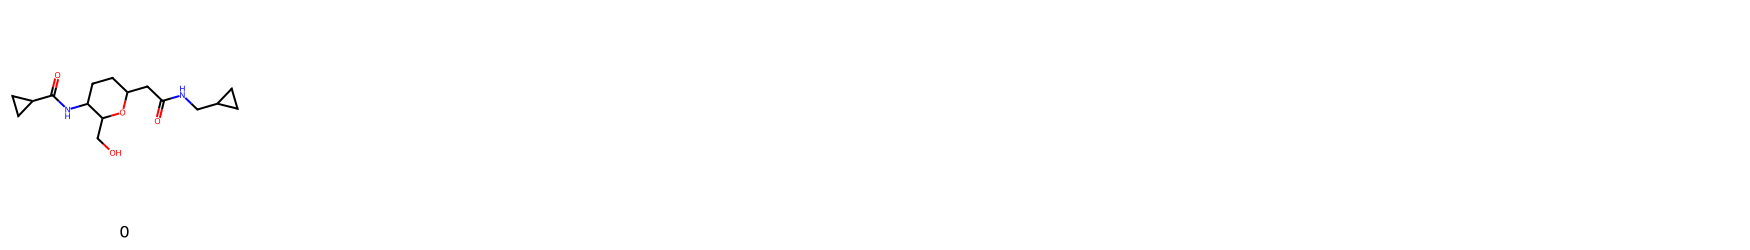

Removed top-5 most similar graphs:


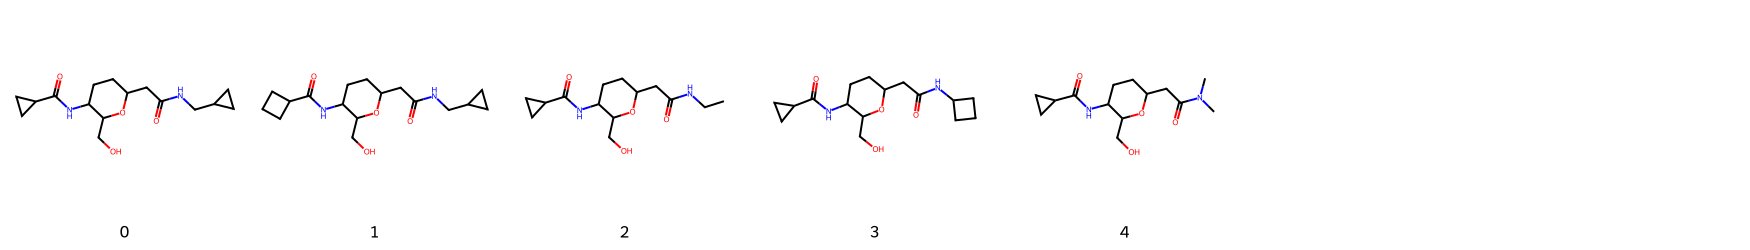

working_graphs: 717
working_targets: 717
working_similarity_target shape: (717,)
cosine target range: [0.3912, 1.0000]


In [8]:
working_graphs, working_similarity_target, anchor_graph, graph_vectorizer = build_similarity_optimization_dataset(
    dataset_type='MOLECULAR',
    dataset_size=6000,
    size=25,
    k_remove=5,
)

Training on 717 pruned graphs with similarity targets in [0.3912, 1.0000]
Fitting model on 717 graphs
Fitting feasibility estimator on 717 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 12 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 102816 pairs (50.00%) from 205632 total pairs (pos=68544, neg=137088, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=34272, neg=68544, positive_ratio=0.333.
Training conditional model on 717 graphs with up to 25 nodes each.
Using direct-edge supervision with 102816 labelled pairs.
Lambda settings: degree=1000.000, node_exist=5000.000, n

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Writing checkpoints to /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/checkpoints/equilibrium_matching/EquilibriumMatchingDecompositionalNodeGenerator_41f512014e87449da7d6879bb63b3e04


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Epoch 10/256 | ETA 0h 49m 17s:
  train total=  59135.4 | equilibrium_matching   51175.1 [86.5%] |        deg     927.6 [1.6%] |      exist     396.6 [0.7%] | node_label    4292.8 [7.3%]
  val   total=  59483.5 | equilibrium_matching   51192.9 [86.1%] |        deg     932.2 [1.6%] |      exist     399.3 [0.7%] | node_label    4646.6 [7.8%]
  train                 | edge_label     668.4 [1.1%] |       edge    1675.0 [2.8%] | dominant=equilibrium_matching [86.5%]
  val                   | edge_label     637.6 [1.1%] |       edge    1674.8 [2.8%] | dominant=equilibrium_matching [86.1%]
Epoch 20/256 | ETA 0h 48m 46s:
  train total=  56571.0 | equilibrium_matching   51168.4 [90.4%] |        deg     851.5 [1.5%] |      exist     353.2 [0.6%] | node_label    2025.1 [3.6%]
  val   total=  56347.6 | equilibrium_matching   51127.6 [90.7%] |        deg     853.2 [1.5%] |      exist     378.1 [0.7%] | node_label    1838.3 [3.3%]
  train                 | edge_label     530.2 [0.9%] |       edge    

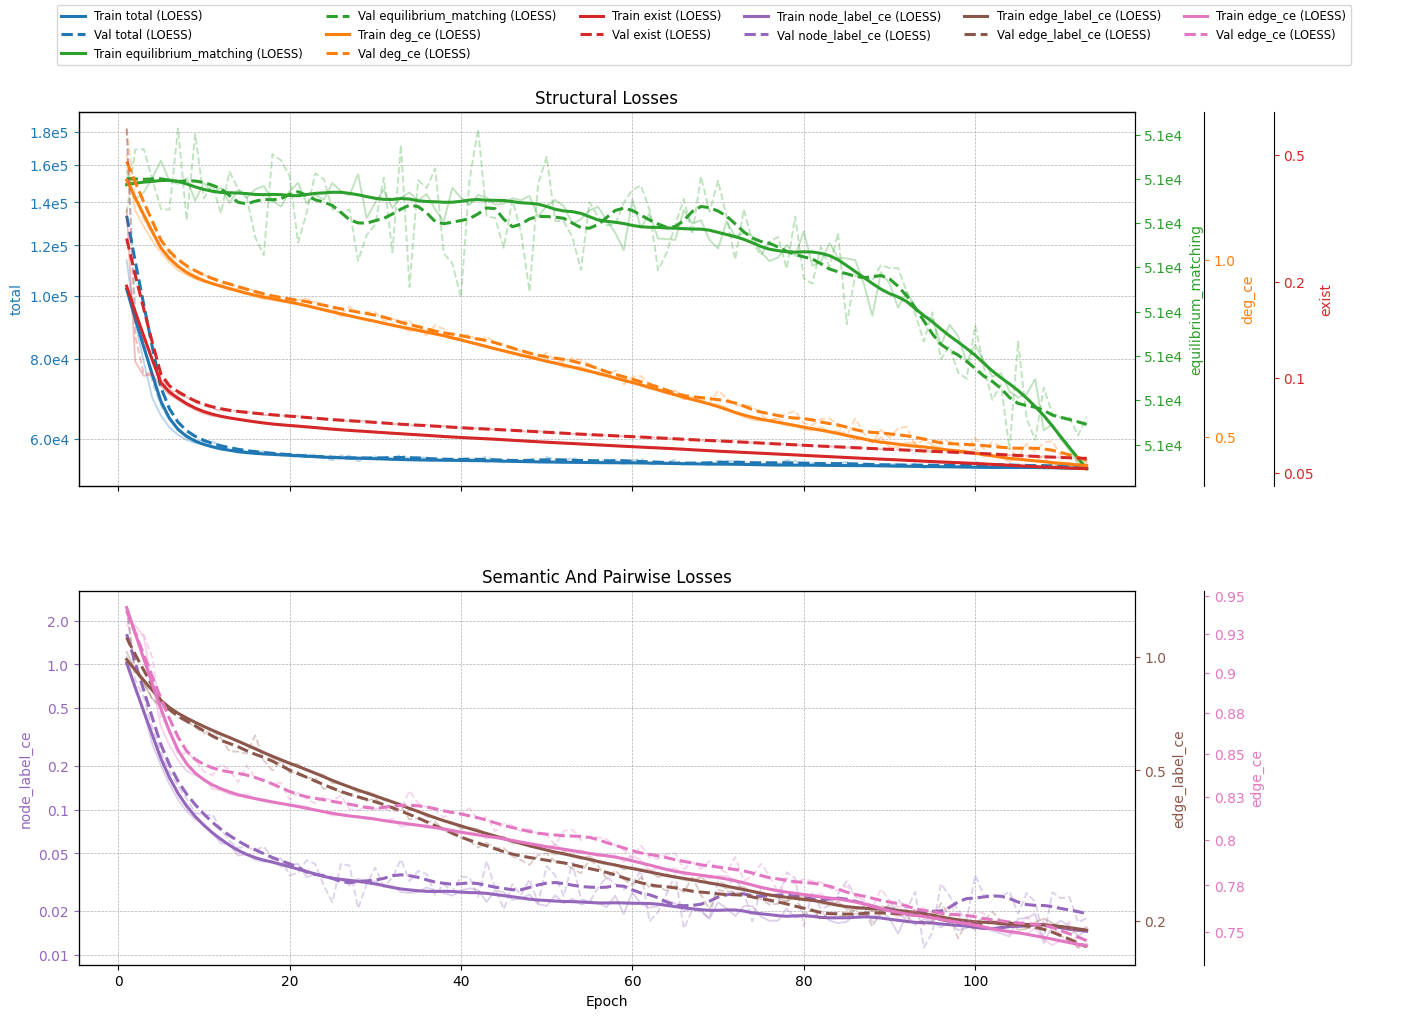

Restored best checkpoint: best_epoch=93, val_total=54084.4648, raw_val_equilibrium_matching=51047.2930, stopped_epoch=114
  path=/Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/checkpoints/equilibrium_matching/EquilibriumMatchingDecompositionalNodeGenerator_41f512014e87449da7d6879bb63b3e04/best-092-54084.4648.ckpt
Saved graph generator to /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/saved_models/similarity_graph_generator.pkl
CPU times: user 3h 3min, sys: 14min 30s, total: 3h 17min 30s
Wall time: 27min 20s


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/saved_models/similarity_graph_generator.pkl')

In [9]:
%%time
similarity_graph_generator = build_graph_generator(
    # General
    verbose=2,
    nbits=11,
    # Network architecture
    latent_embedding_dimension=96,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    transformer_dropout=0.15,
    # Training
    learning_rate=1e-4,
    maximum_epochs=256,
    batch_size=16,
    total_steps=100,
    verbose_epoch_interval=10,
    enable_early_stopping=True,
    early_stopping_monitor="val_total",
    early_stopping_mode="min",
    early_stopping_patience=20,
    early_stopping_min_delta=5.2e4 * 1e-3,
    early_stopping_ema_alpha=0.3,
    restore_best_checkpoint=True,
    important_feature_index=1,
    # Loss weights
    lambda_degree_importance=1e3,
    default_exist_pos_weight=1.0,
    lambda_node_exist_importance=5e3,
    lambda_node_count_importance=0.0,
    lambda_node_label_importance=5e4,
    lambda_edge_label_importance=1e3,
    lambda_direct_edge_importance=2e3,
    lambda_edge_count_importance=0.0,
    lambda_degree_edge_consistency_importance=0.0,
    lambda_auxiliary_edge_importance=1.0,
    # Sampling and guidance
    degree_temperature=1,
    pool_condition_tokens=False,
    equilibrium_matching_sigma=0.2,
    sampling_step_size=0.05,
    sampling_steps=None,
    langevin_noise_scale=0.0,
    cfg_condition_dropout_prob=0.1,
    cfg_null_target_strategy="zero",
    target_classification_max_distinct=20,
    # Locality supervision and generation
    locality_horizon=1,
    locality_sample_fraction=0.5,
    negative_sample_factor=1,
    locality_sampling_strategy="stratified_preserve",
    locality_target_positive_ratio=0.5,
    use_feasibility_filtering=True,
    max_feasibility_attempts=10,
    feasibility_candidates_per_attempt=4,
    feasibility_failure_mode="return_partial",
    # Decoder
    decoder_existence_threshold=0.5,
    decoder_enforce_connectivity=True,
    decoder_degree_slack_penalty=1e6,
    decoder_warm_start_mst=True,
    decoder_n_jobs=1,
    # Outputs
    artifact_root=REPO_ROOT / ".artifacts",
    checkpoint_root=REPO_ROOT / ".artifacts" / "checkpoints" / "equilibrium_matching",
)

print(f"Training on {len(working_graphs)} pruned graphs with similarity targets in [{working_similarity_target.min():.4f}, {working_similarity_target.max():.4f}]")
_ = similarity_graph_generator.fit(
    working_graphs,
    targets=working_similarity_target,
)

# Save trained generator
save_graph_generator(similarity_graph_generator)


Loaded graph generator from /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/saved_models/similarity_graph_generator.pkl


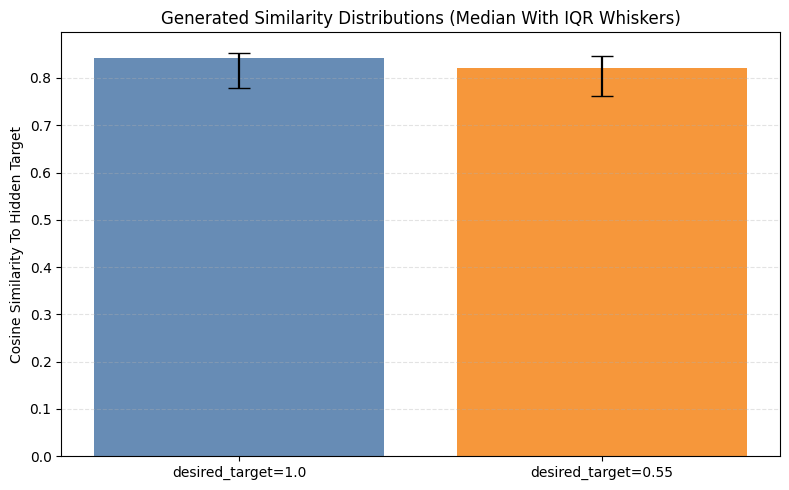

desired_target=1.0 -> n=14, median=0.8416, q1=0.7790, q3=0.8538
desired_target=0.55 -> n=14, median=0.8216, q1=0.7616, q3=0.8472
median(high) - median(low) = 0.0201


In [14]:
# Reload generator from disk before sampling
similarity_graph_generator = load_graph_generator(MODEL_PATH)

apply_feasibility_filtering = False
n_samples = 14

generated_high = similarity_graph_generator.sample_conditioned_on_random(
    working_graphs,
    n_samples=n_samples,
    desired_target=1.0,
    guidance_scale=4.0,
    apply_feasibility_filtering=apply_feasibility_filtering,
)

generated_low = similarity_graph_generator.sample_conditioned_on_random(
    working_graphs,
    n_samples=n_samples,
    desired_target=0.55,
    guidance_scale=4.0,
    apply_feasibility_filtering=apply_feasibility_filtering,
)

# Similarity vectors for generated samples vs hidden target
sim_high = cosine_to_hidden_target(generated_high, anchor_graph, graph_vectorizer)
sim_low = cosine_to_hidden_target(generated_low, anchor_graph, graph_vectorizer)

# Plot + summary stats in one utility call
similarity_stats = plot_similarity_distribution_with_iqr(
    sim_high=sim_high,
    sim_low=sim_low,
    target_high=1.0,
    target_low=0.55,
)


Anchor graph:


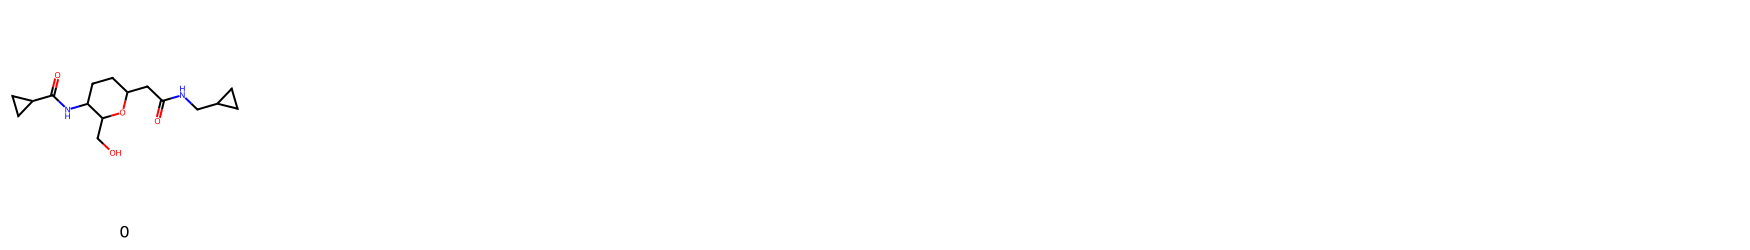

Sample generations for desired_target=1.0
[0.8805244  0.87469476 0.8714682  0.8542097  0.85275984 0.8521912
 0.8463461  0.8368901  0.8215605  0.8055345  0.7701905  0.7693737
 0.6969619  0.69271404]


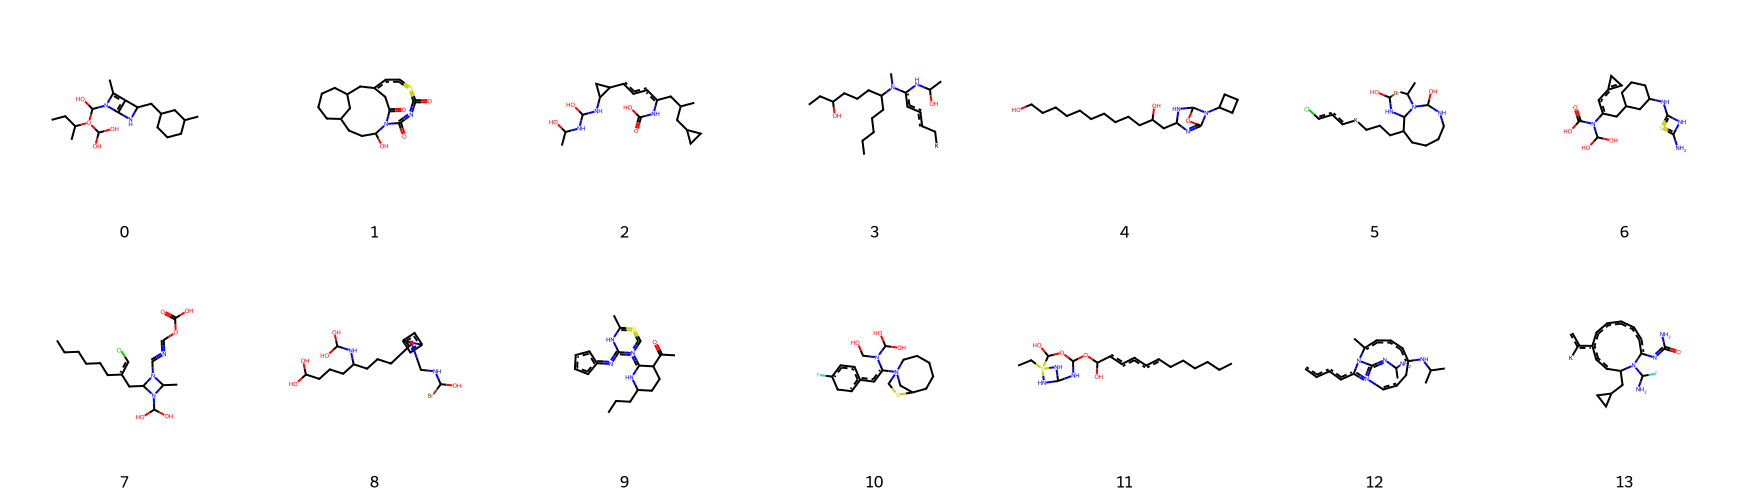

Sample generations for desired_target=0.7
[0.876573   0.86348474 0.8608764  0.8496292  0.83990985 0.82720983
 0.8235298  0.819578   0.7858047  0.76163286 0.7616117  0.75436723
 0.74975324 0.7004908 ]


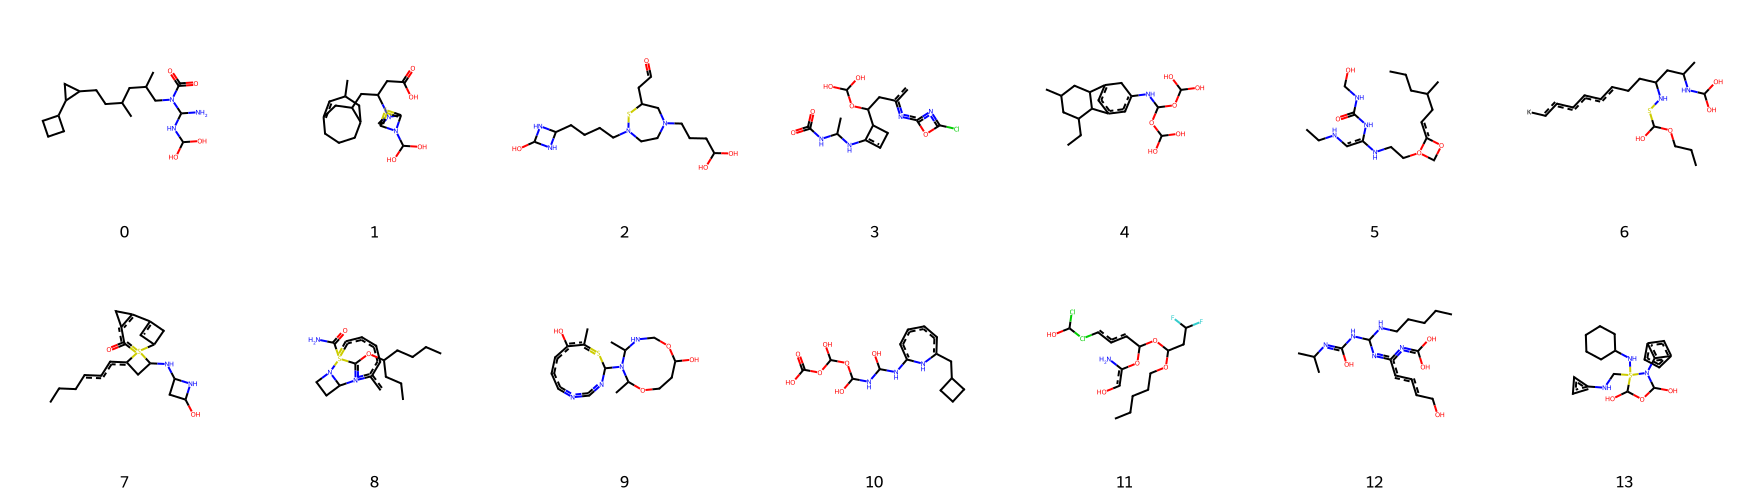

In [20]:
from notebooks.notebook_utils import infer_display_mode, plot_networkx_graphs
display_mode = infer_display_mode(working_graphs)

high_order = np.argsort(-sim_high)
low_order = np.argsort(-sim_low)
sorted_generated_high = [generated_high[index] for index in high_order]
sorted_generated_low = [generated_low[index] for index in low_order]
sorted_sim_high = sim_high[high_order]
sorted_sim_low = sim_low[low_order]

print("Anchor graph:")
plot_networkx_graphs([anchor_graph], n_cols=1, mode=display_mode)

print('Sample generations for desired_target=1.0')
print(sorted_sim_high)
plot_networkx_graphs(
    sorted_generated_high,
    n_cols=min(6, max(1, len(sorted_generated_high[:6]))),
    mode=display_mode,
    titles=[f"sim={value:.3f}" for value in sorted_sim_high[:6]],
)

print('Sample generations for desired_target=0.7')
print(sorted_sim_low)
plot_networkx_graphs(
    sorted_generated_low,
    n_cols=min(6, max(1, len(sorted_generated_low[:6]))),
    mode=display_mode,
    titles=[f"sim={value:.3f}" for value in sorted_sim_low[:6]],
)
